# 5. Univariate EDA <a id="5-univariate-eda" name="5-univariate-eda"></a>

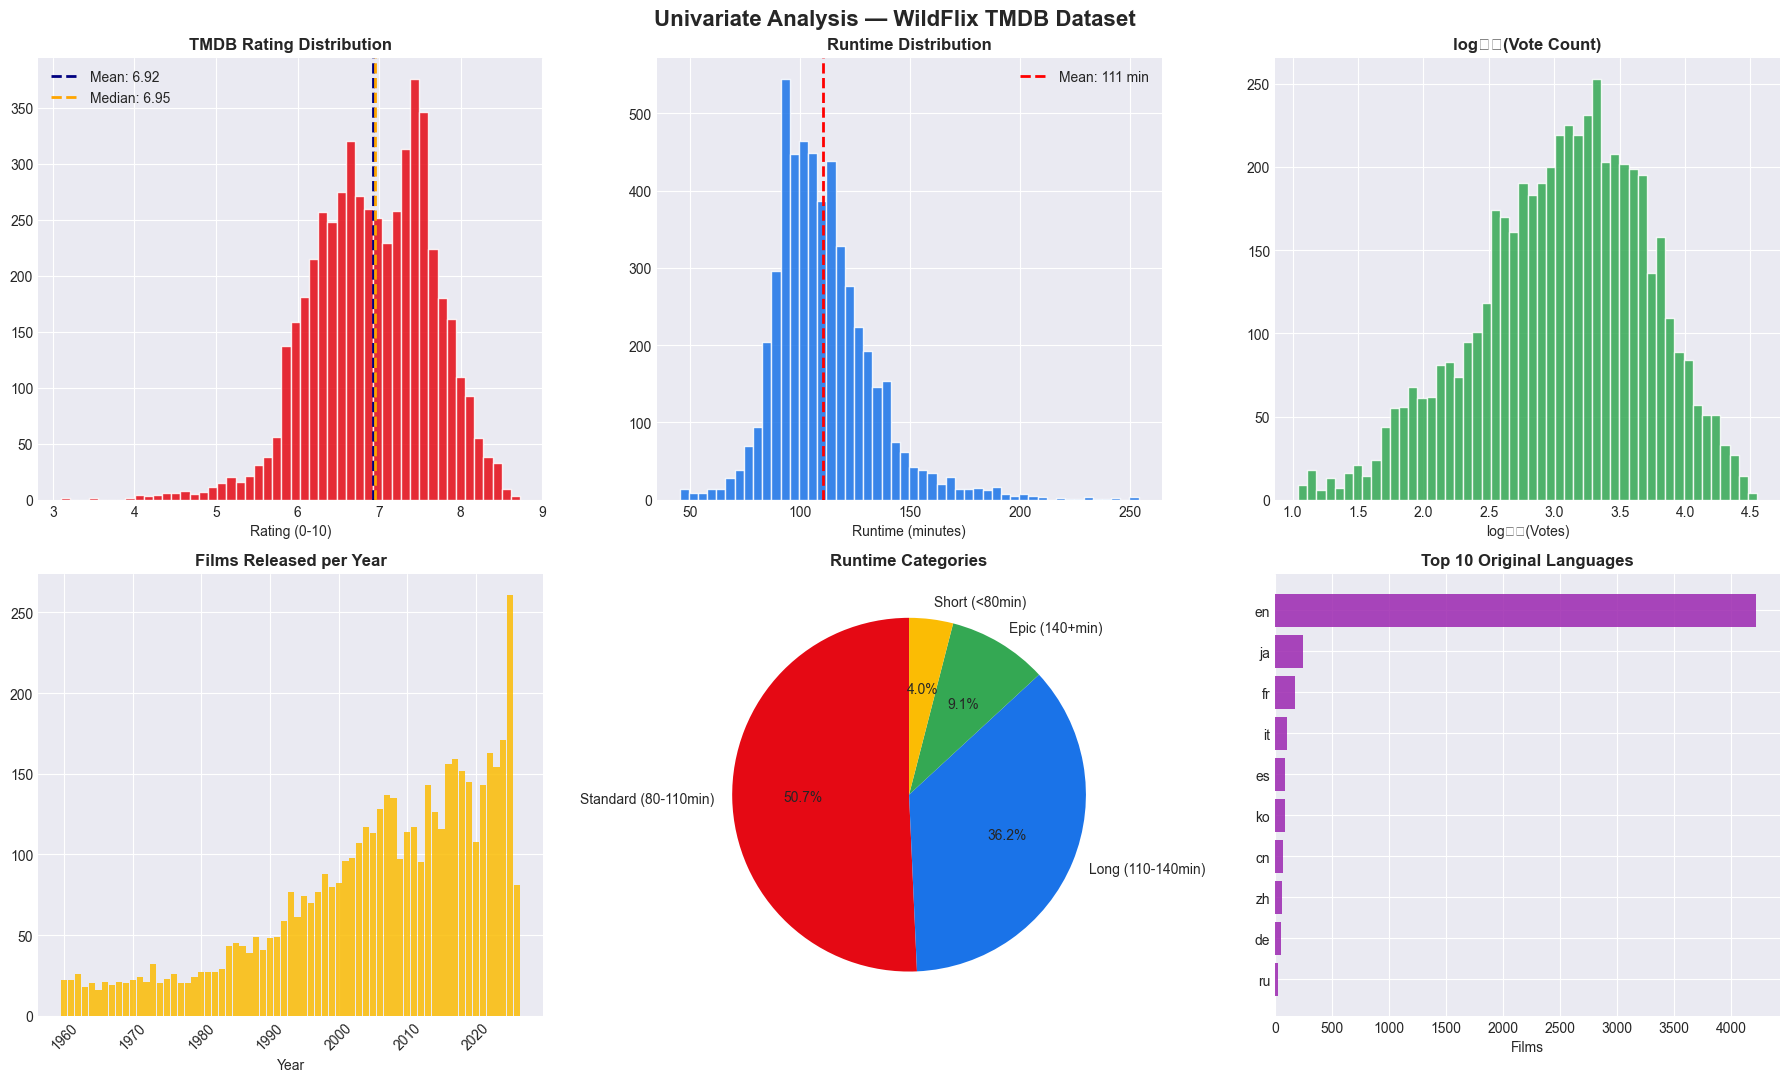

 Saved: fig_01_univariate.png


In [ ]:
# Rating distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Univariate Analysis — WildFlix TMDB Dataset", fontsize=16, fontweight="bold")

# 1. Rating histogram
axes[0,0].hist(df["vote_average"], bins=50, color="#e50914", edgecolor="white", alpha=0.85)
axes[0,0].axvline(df["vote_average"].mean(),   color="navy",   linestyle="--", lw=2, label=f"Mean: {df['vote_average'].mean():.2f}")
axes[0,0].axvline(df["vote_average"].median(), color="orange", linestyle="--", lw=2, label=f"Median: {df['vote_average'].median():.2f}")
axes[0,0].set_title("TMDB Rating Distribution", fontweight="bold")
axes[0,0].set_xlabel("Rating (0-10)"); axes[0,0].legend()

# 2. Runtime
axes[0,1].hist(df["runtime"], bins=50, color="#1a73e8", edgecolor="white", alpha=0.85)
axes[0,1].axvline(df["runtime"].mean(), color="red", linestyle="--", lw=2, label=f"Mean: {df['runtime'].mean():.0f} min")
axes[0,1].set_title("Runtime Distribution", fontweight="bold")
axes[0,1].set_xlabel("Runtime (minutes)"); axes[0,1].legend()

# 3. Vote count (log)
axes[0,2].hist(np.log10(df["vote_count"]+1), bins=50, color="#34a853", edgecolor="white", alpha=0.85)
axes[0,2].set_title("log₁₀(Vote Count)", fontweight="bold")
axes[0,2].set_xlabel("log₁₀(Votes)")

# 4. Films per year
yc = df["release_year"].value_counts().sort_index()
yc_plot = yc[yc.index >= 1960]
axes[1,0].bar(yc_plot.index.astype(int), yc_plot.values, color="#fbbc04", alpha=0.85, width=0.9)
axes[1,0].set_title("Films Released per Year", fontweight="bold")
axes[1,0].set_xlabel("Year"); axes[1,0].tick_params(axis="x", rotation=45)

# 5. Runtime categories
rc = df["runtime_category"].value_counts()
wedge_colors = ["#e50914","#1a73e8","#34a853","#fbbc04"]
axes[1,1].pie(rc.values, labels=rc.index, autopct="%1.1f%%", colors=wedge_colors[:len(rc)], startangle=90)
axes[1,1].set_title("Runtime Categories", fontweight="bold")

# 6. Top languages
lc = df["original_language"].value_counts().head(10)
axes[1,2].barh(lc.index, lc.values, color="#9c27b0", alpha=0.85)
axes[1,2].set_title("Top 10 Original Languages", fontweight="bold")
axes[1,2].set_xlabel("Films"); axes[1,2].invert_yaxis()

plt.tight_layout()
plt.savefig("../exports/fig_01_univariate.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: fig_01_univariate.png")

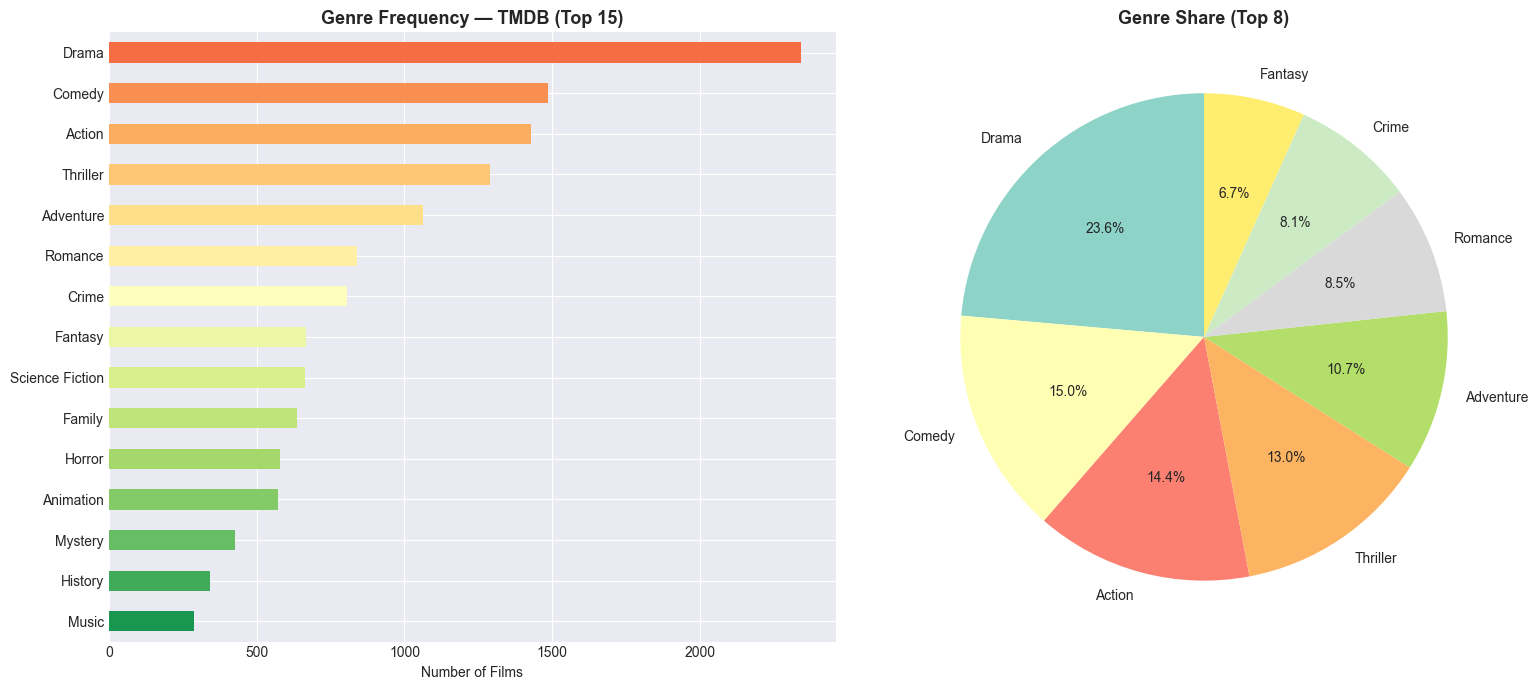


Top 15 genres from TMDB data:
Drama              2342
Comedy             1487
Action             1428
Thriller           1291
Adventure          1061
Romance             839
Crime               807
Fantasy             666
Science Fiction     663
Family              635
Horror              579
Animation           572
Mystery             428
History             341
Music               287


In [ ]:
# Genre frequency
all_genres = []
for g in df["genres"].dropna():
    all_genres.extend([x.strip() for x in str(g).split(",") if x.strip()])
genre_counts = pd.Series(all_genres).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar
genre_counts.head(15).plot(kind="barh", ax=axes[0],
    color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, 15)))
axes[0].set_title("Genre Frequency — TMDB (Top 15)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Films"); axes[0].invert_yaxis()

# Pie top 8
top8 = genre_counts.head(8)
axes[1].pie(top8.values, labels=top8.index, autopct="%1.1f%%", startangle=90,
            colors=plt.cm.Set3(np.linspace(0, 1, 8)))
axes[1].set_title("Genre Share (Top 8)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../exports/fig_02_genres.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 15 genres from TMDB data:")
print(genre_counts.head(15).to_string())

**Drama :**

Account for 23.6% of the dataset on its own. Many movies will have Drama as their primary genre, risking recommendations that are too similar—we will need to use secondary genres as well.

**Comedy + Action + Thriller :**

Make up 42% combined; these are the genres that attract the largest audiences.

**Science Fiction / Fantasy :**

Separated but close in frequency, often combined within the same movies (e.g., Star Wars = Sci-Fi + Adventure + Fantasy).

**Animation + Family :**

The system will be able to recommend family-friendly movies.

**History + Music at the bottom of the list :**

Niche genres with few movies, but a very loyal audience.

More than 1 out of 2 movies feature Drama, Comedy, or Action; these are the 3 most common genres.

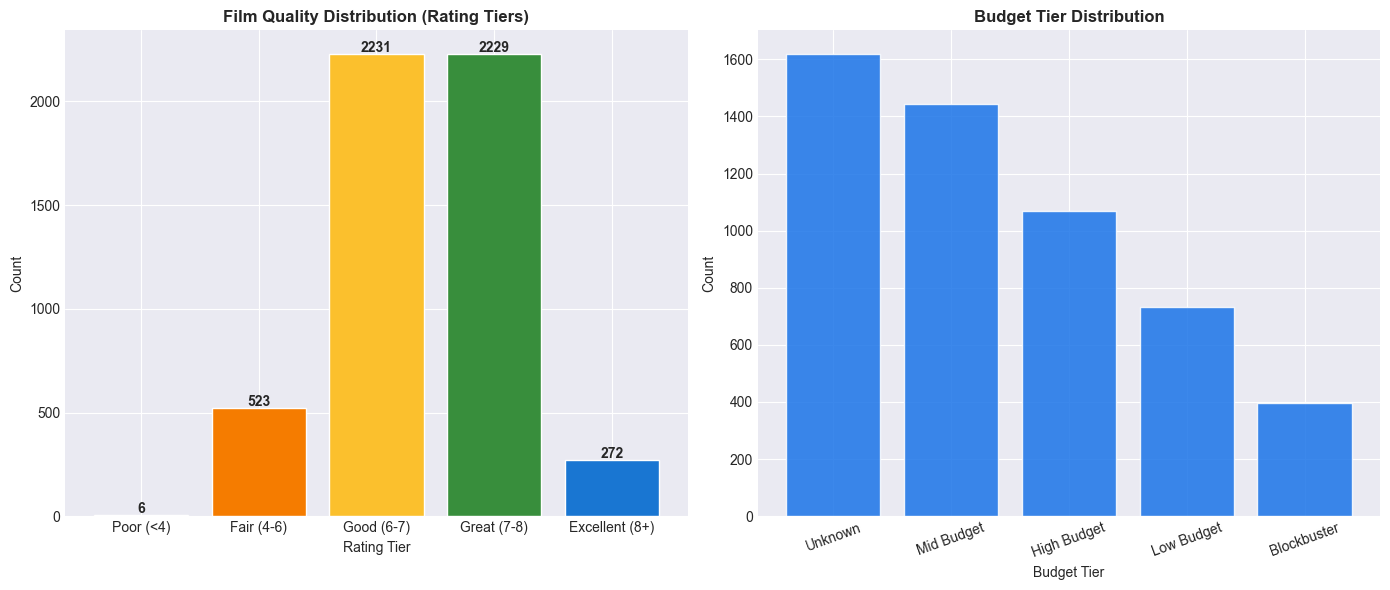

In [ ]:
# Rating tier & budget tier
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rt = df["rating_tier"].value_counts().sort_index()
axes[0].bar(rt.index.astype(str), rt.values,
    color=["#d32f2f","#f57c00","#fbc02d","#388e3c","#1976d2"], edgecolor="white")
axes[0].set_title("Film Quality Distribution (Rating Tiers)", fontweight="bold")
axes[0].set_xlabel("Rating Tier"); axes[0].set_ylabel("Count")
for i, v in enumerate(rt.values):
    axes[0].text(i, v+10, str(v), ha="center", fontweight="bold")

bt = df["budget_tier"].value_counts()
axes[1].bar(bt.index.astype(str), bt.values, color="#1a73e8", alpha=0.85, edgecolor="white")
axes[1].set_title("Budget Tier Distribution", fontweight="bold")
axes[1].set_xlabel("Budget Tier"); axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../exports/fig_03_tiers.png", dpi=150, bbox_inches="tight")
plt.show()

**Poor (6 movies) :**

Our `vote_count >= 10` filter perfectly cleaned out poorly rated movies without an audience. The 6 remaining movies with rating < 4 are genuinely bad films.

**Good + Great (84.8% of the dataset) :**

The vast majority of movies fall between 6 and 8, perfectly aligning with our average of 6.83. Highly symmetric distribution between Good and Great (nearly identical: 2,231 vs. 2,229), confirming that 6.83 is truly the median of the dataset.

**Excellent (272 movies, 5.2%) :**

True masterpieces are genuinely rare >>> these will serve as the premium recommendations in our system.

**Fair (523 movies, 9.9%) :**

Decent movies, but below average—useful for diversifying recommendations.

**Unknown (30.4%) :**

1 out of 3 movies has no declared budget, mainly independent, foreign, or older films. These will be excluded from the Power BI financial analysis.

**Mid Budget (27.4%) :**

Movies between $5M and $30M—the core of the movie industry ("Comedies, Thrillers, Dramas").

**High Budget (20.2%) :**

Movies between $30M and $100M—major productions.

**Low Budget (14.1%) :**

Movies under $5M—independent cinema, auteur films, often featuring the best rating-to-budget ratios.

**Blockbuster (7.6%) :**

400 movies with a budget > $100M (Marvel, Disney, major animated films). These generate the highest revenue and popularity.

**Budget vs. Quality Correlation ?**

The "Blockbuster Paradox" : higher budgets yield higher revenues, but not necessarily better ratings. This will be a key focus of our Power BI financial analysis.